# Unit11_Example_05 | 化工案例五：管道壓力脈動之 PSD 分析與泵浦葉片通過頻率識別

本 Notebook 使用 `scipy.fft` 模組對離心泵浦管道壓力脈動訊號進行**功率頻譜密度 (PSD) 分析**，透過 Periodogram 與手動 Welch 法識別**葉片通過頻率 (BPF)** 及其諧波。

## 目標
- 理解 BPF 的物理意義： $f_{\mathrm{BPF}} = (n_{\mathrm{rpm}}/60) \times Z_{\mathrm{blade}}$
- 使用 `scipy.fft.rfft()` 計算 Periodogram PSD（觀察高方差問題）
- 以迴圈手動實作 Welch 法（分段、加 Hann 視窗、FFT 後平均）
- 使用 `scipy.fft.next_fast_len()` 零填充精確定位 BPF 各諧波
- 計算諧波能量分布，評估泵浦運行狀態
- 以 `scipy.signal.welch()` 驗證手動 Welch 法結果等價性

## 內容大綱
- **0.** 環境設定
- **1.** 載入套件
- **2.** 合成泵浦壓力脈動訊號
- **3.** 方法一：直接 Periodogram PSD
- **4.** 方法二：手動 Welch 法 PSD
- **5.** 兩種方法頻譜比較
- **6.** 零填充精確定位 BPF 諧波
- **7.** 諧波能量計算與分布
- **8.** 補充：`scipy.signal.welch()` 驗證

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit11_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit11'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit11
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_05\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.fft import rfft, rfftfreq, next_fast_len
from scipy.signal import welch as scipy_welch

# ========================================
# 繪圖樣式設定
# ========================================
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
import matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 合成泵浦壓力脈動訊號

離心泵浦以轉速 $n_{\mathrm{rpm}} = 1450$ RPM 運行，葉片數 $Z = 5$ ，葉片通過頻率：

$$
f_{\mathrm{BPF}} = \frac{1450}{60} \times 5 = 120.833 \text{ Hz}
$$

訊號模型：

$$
p(t) = \mu + A_{\mathrm{rot}}\sin(2\pi f_{\mathrm{rot}} t) + A_{\mathrm{BPF}}\sin(2\pi f_{\mathrm{BPF}} t + \phi_{\mathrm{BPF}}) + A_{2\mathrm{BPF}}\sin(4\pi f_{\mathrm{BPF}} t + \phi_{2\mathrm{BPF}}) + A_{3\mathrm{BPF}}\sin(6\pi f_{\mathrm{BPF}} t + \phi_{3\mathrm{BPF}}) + \sigma\varepsilon(t)
$$

  泵浦壓力脈動訊號參數
  轉速       = 1450 RPM
  葉片數     = 5
  轉頻 f_rot = 24.167 Hz
  BPF  f_bpf = 120.833 Hz
  2×BPF      = 241.667 Hz
  3×BPF      = 362.500 Hz
  取樣頻率   = 1000 Hz,  訊號長度 = 10000 點 (10.0 s)
  頻率解析度 = 0.100 Hz,  奈奎斯特 = 500 Hz

  理論 BPF 峰值功率:        32.00 kPa²
  理論 2×BPF 峰值功率:      4.50 kPa²
  理論 3×BPF 峰值功率:      0.72 kPa²


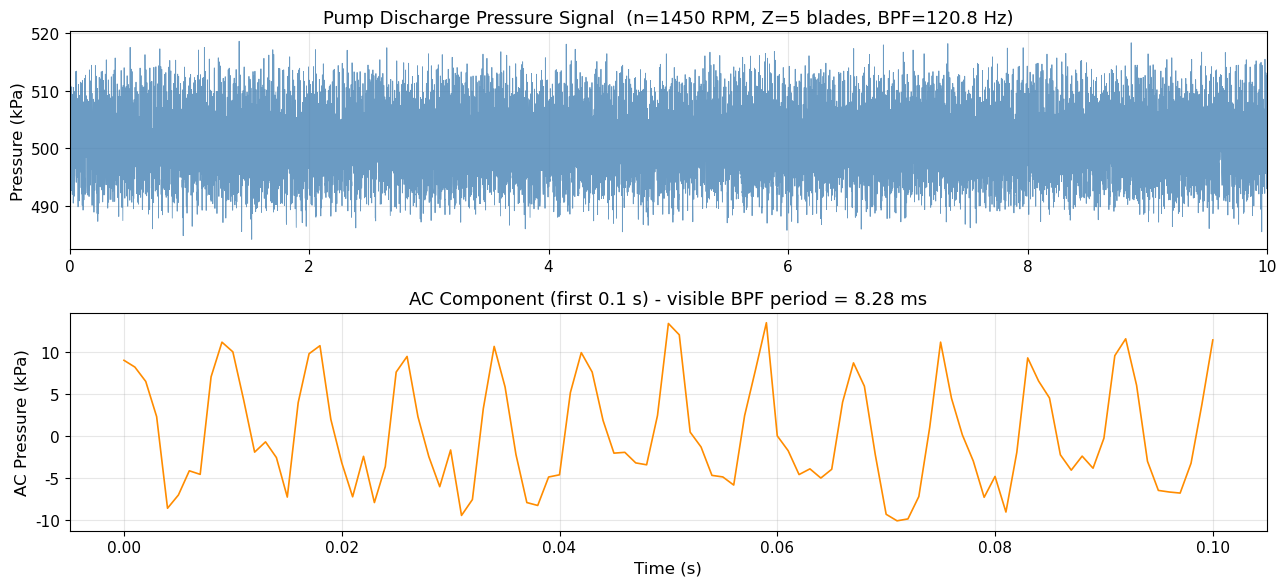

✓ 時域圖已儲存


In [3]:
# ========================================
# 泵浦與訊號參數
# ========================================
n_rpm   = 1450.0          # 轉速 (RPM)
Z       = 5               # 葉片數
fs      = 1000.0          # 取樣頻率 (Hz)
T       = 10.0            # 訊號長度 (s)
N       = int(T * fs)     # 總點數 10000
t       = np.arange(N) / fs

f_rot   = n_rpm / 60.0                  # 轉頻 = 24.167 Hz
f_bpf   = f_rot * Z                     # BPF  = 120.833 Hz

# 各成分振幅與相位
A_rot   = 2.0
A_bpf   = 8.0;   phi_bpf  = np.pi / 4
A_2bpf  = 3.0;   phi_2bpf = np.pi / 6
A_3bpf  = 1.2;   phi_3bpf = np.pi / 3
mu      = 500.0           # 靜壓均值 (kPa)
sigma   = 2.5             # 雜訊標準差 (kPa)

rng = np.random.default_rng(seed=42)

# 合成訊號
p = (mu
     + A_rot  * np.sin(2 * np.pi * f_rot  * t)
     + A_bpf  * np.sin(2 * np.pi * f_bpf  * t + phi_bpf)
     + A_2bpf * np.sin(2 * np.pi * 2*f_bpf * t + phi_2bpf)
     + A_3bpf * np.sin(2 * np.pi * 3*f_bpf * t + phi_3bpf)
     + sigma  * rng.standard_normal(N))

print("=" * 50)
print("  泵浦壓力脈動訊號參數")
print("=" * 50)
print(f"  轉速       = {n_rpm:.0f} RPM")
print(f"  葉片數     = {Z}")
print(f"  轉頻 f_rot = {f_rot:.3f} Hz")
print(f"  BPF  f_bpf = {f_bpf:.3f} Hz")
print(f"  2×BPF      = {2*f_bpf:.3f} Hz")
print(f"  3×BPF      = {3*f_bpf:.3f} Hz")
print(f"  取樣頻率   = {fs:.0f} Hz,  訊號長度 = {N} 點 ({T:.1f} s)")
print(f"  頻率解析度 = {fs/N:.3f} Hz,  奈奎斯特 = {fs/2:.0f} Hz")
print()
print(f"  理論 BPF 峰值功率:        {A_bpf**2/2:.2f} kPa²")
print(f"  理論 2×BPF 峰值功率:      {A_2bpf**2/2:.2f} kPa²")
print(f"  理論 3×BPF 峰值功率:      {A_3bpf**2/2:.2f} kPa²")

# ----------------------------------------
# 繪製時域訊號
# ----------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

# 上圖：完整訊號（含靜壓）
ax1 = axes[0]
ax1.plot(t, p, color='steelblue', lw=0.6, alpha=0.8)
ax1.set_ylabel('Pressure (kPa)')
ax1.set_title(f'Pump Discharge Pressure Signal  (n={n_rpm:.0f} RPM, Z={Z} blades, BPF={f_bpf:.1f} Hz)')
ax1.set_xlim([0, T])

# 下圖：去靜壓後的交流成分（前 0.1 s 局部放大）
ax2 = axes[1]
idx_zoom = t <= 0.1
p_ac_temp = p - np.mean(p)
ax2.plot(t[idx_zoom], p_ac_temp[idx_zoom], color='darkorange', lw=1.2)
ax2.set_ylabel('AC Pressure (kPa)')
ax2.set_xlabel('Time (s)')
ax2.set_title(f'AC Component (first 0.1 s) - visible BPF period = {1/f_bpf*1000:.2f} ms')

plt.tight_layout()
plt.savefig(FIG_DIR / 'pump_signal_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 時域圖已儲存")

---
### 3. 方法一：直接 Periodogram PSD

對完整訊號（去均值後）進行 FFT，計算單邊 PSD：

$$
\hat{S}_{\mathrm{per}}(f_k) = \frac{2}{f_s \cdot N} \left|X[k]\right|^2, \quad \Delta f = \frac{f_s}{N} = \frac{1000}{10000} = 0.1 \text{ Hz}
$$

**問題：** Periodogram 方差不隨 $N$ 降低，頻譜呈現明顯「毛刺」現象。

  Periodogram PSD 計算結果
  頻率解析度 Δf  = 0.1000 Hz
  頻率軸點數     = 5001
  PSD 最大值     = 212.58 kPa²/Hz @ 120.800 Hz
  BPF 頻點 PSD   = 212.58 kPa²/Hz @ 120.800 Hz


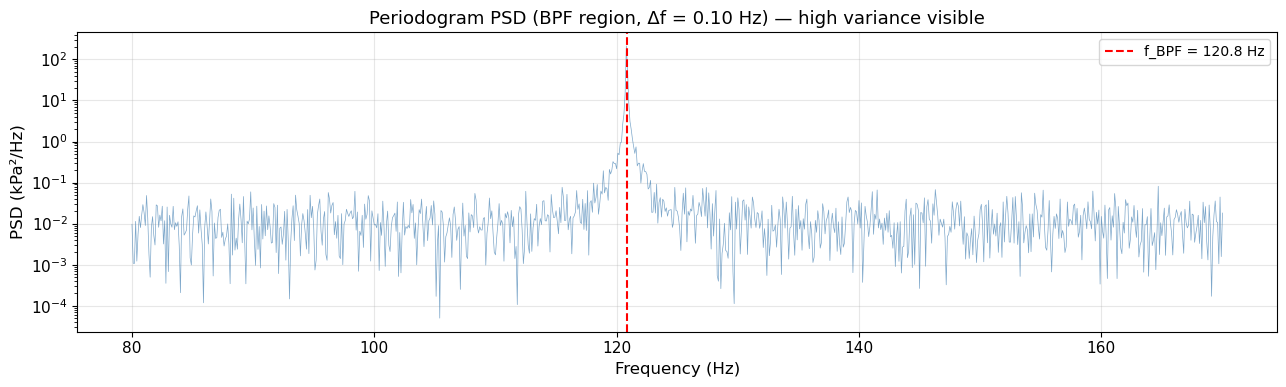


觀察：BPF 峰值附近頻譜毛刺明顯，隨機方差大，難以判斷真實峰值。


In [4]:
# ========================================
# 去均值 (去除 DC 分量)
# ========================================
p_ac = p - np.mean(p)

# ========================================
# 直接 Periodogram (整段 FFT)
# ========================================
X_full   = rfft(p_ac)                     # 單邊複數頻譜，長度 N//2+1
freqs    = rfftfreq(N, d=1.0/fs)          # 頻率軸 (Hz)

# 單邊 PSD：非 DC/Nyquist 頻點乘以 2，除以 fs*N
S_per    = (2.0 / (fs * N)) * np.abs(X_full) ** 2
S_per[0] /= 2.0                           # DC 項不乘 2
if N % 2 == 0:
    S_per[-1] /= 2.0                      # Nyquist 項不乘 2

# 找 BPF 峰值
bpf_idx  = np.argmin(np.abs(freqs - f_bpf))
print("=" * 50)
print("  Periodogram PSD 計算結果")
print("=" * 50)
print(f"  頻率解析度 Δf  = {fs/N:.4f} Hz")
print(f"  頻率軸點數     = {len(freqs)}")
print(f"  PSD 最大值     = {S_per.max():.2f} kPa²/Hz @ {freqs[np.argmax(S_per)]:.3f} Hz")
print(f"  BPF 頻點 PSD   = {S_per[bpf_idx]:.2f} kPa²/Hz @ {freqs[bpf_idx]:.3f} Hz")

# ----------------------------------------
# 頻譜快速預覽（局部 BPF 附近）
# ----------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))
mask_bpf = (freqs >= 80) & (freqs <= 170)
ax.semilogy(freqs[mask_bpf], S_per[mask_bpf], color='steelblue', lw=0.5, alpha=0.7)
ax.axvline(f_bpf, color='red', ls='--', lw=1.5, label=f'f_BPF = {f_bpf:.1f} Hz')
ax.set_title(f'Periodogram PSD (BPF region, Δf = {fs/N:.2f} Hz) — high variance visible')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (kPa²/Hz)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\n觀察：BPF 峰值附近頻譜毛刺明顯，隨機方差大，難以判斷真實峰值。")

---
### 4. 方法二：手動 Welch 法 PSD

**Welch 法步驟：** 分段 → 加 Hann 視窗 → 各段 FFT → 取平均

$$
\hat{S}_{\mathrm{Welch}}[k] = \frac{1}{K} \sum_{i=0}^{K-1} \frac{2}{f_s \cdot U} \left|X_i[k]\right|^2, \quad U = \sum_{m} w^2[m]
$$

本範例設定：每段長度 $M = 2048$ 點（ $\Delta f = f_s/M \approx 0.488$ Hz），跳躍步長 $D = 1024$ 點（50% 重疊）。

In [5]:
# ========================================
# Welch 法參數
# ========================================
M      = 2048              # 每段長度 (點)
D      = M // 2            # 跳躍步長 = 1024 (50% 重疊)
K_max  = (N - M) // D + 1  # 最大段數

# Hann 視窗與視窗能量正規化因子
win    = np.hanning(M)
U      = np.sum(win ** 2)

# Welch 頻率軸
freqs_welch = rfftfreq(M, d=1.0/fs)
S_welch     = np.zeros(len(freqs_welch))
K_actual    = 0

for i in range(K_max):
    start = i * D
    seg   = p_ac[start : start + M]
    if len(seg) < M:
        break
    seg_win  = seg * win
    X_i      = rfft(seg_win)
    P_i      = (2.0 / (fs * U)) * np.abs(X_i) ** 2
    P_i[0]  /= 2.0
    if M % 2 == 0:
        P_i[-1] /= 2.0
    S_welch += P_i
    K_actual += 1

S_welch /= K_actual                     # 取 K 段平均

bpf_w_idx = np.argmin(np.abs(freqs_welch - f_bpf))

print("=" * 50)
print("  手動 Welch 法 PSD 計算結果")
print("=" * 50)
print(f"  每段長度  M  = {M}  點  (Δf = {fs/M:.4f} Hz)")
print(f"  跳躍步長  D  = {D}  點  (重疊率 = {100*(1-D/M):.0f}%)")
print(f"  總段數    K  = {K_actual}")
print(f"  理論方差縮小倍數 ≈ 1/{K_actual}")
print()
print(f"  頻率軸點數       = {len(freqs_welch)}")
print(f"  PSD 最大值       = {S_welch.max():.2f} kPa²/Hz @ {freqs_welch[np.argmax(S_welch)]:.4f} Hz")
print(f"  BPF 頻點 PSD     = {S_welch[bpf_w_idx]:.2f} kPa²/Hz @ {freqs_welch[bpf_w_idx]:.4f} Hz")

  手動 Welch 法 PSD 計算結果
  每段長度  M  = 2048  點  (Δf = 0.4883 Hz)
  跳躍步長  D  = 1024  點  (重疊率 = 50%)
  總段數    K  = 8
  理論方差縮小倍數 ≈ 1/8

  頻率軸點數       = 1025
  PSD 最大值       = 32.13 kPa²/Hz @ 120.6055 Hz
  BPF 頻點 PSD     = 32.13 kPa²/Hz @ 120.6055 Hz


---
### 5. 兩種方法頻譜比較

比較 Periodogram（高方差）與 Welch 法（低方差）的頻譜平滑程度，觀察 BPF 及諧波峰值的可辨識度差異。

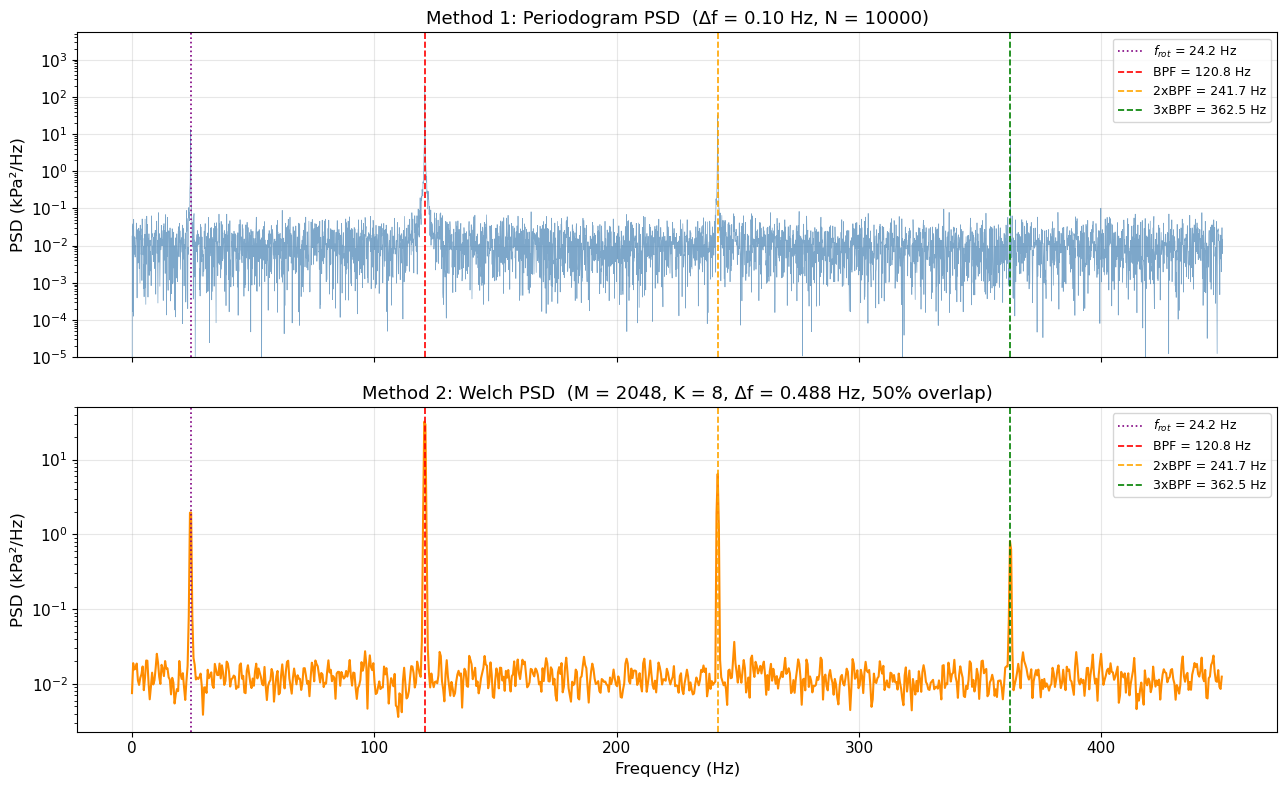

✓ 比較圖已儲存

觀察重點：
  Periodogram：BPF 峰值雖可見，但鄰近頻點毛刺嚴重（方差高）
  Welch 法：   BPF、2×BPF、3×BPF 峰值清晰突出於平坦的雜訊底線


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# 定義標記頻率
freq_markers = {
    f'$f_{{rot}}$ = {f_rot:.1f} Hz': (f_rot, 'purple', ':'),
    f'BPF = {f_bpf:.1f} Hz':        (f_bpf,  'red',    '--'),
    f'2xBPF = {2*f_bpf:.1f} Hz':    (2*f_bpf,'orange', '--'),
    f'3xBPF = {3*f_bpf:.1f} Hz':    (3*f_bpf,'green',  '--'),
}

# --- 上圖：Periodogram ---
ax1 = axes[0]
freq_mask = freqs <= 450
ax1.semilogy(freqs[freq_mask], S_per[freq_mask],
             color='steelblue', lw=0.5, alpha=0.7)
for label, (fc_freq, fc_color, fc_ls) in freq_markers.items():
    ax1.axvline(fc_freq, color=fc_color, ls=fc_ls, lw=1.2, label=label)
ax1.set_ylabel('PSD (kPa²/Hz)')
ax1.set_title(f'Method 1: Periodogram PSD  (Δf = {fs/N:.2f} Hz, N = {N})')
ax1.set_ylim(bottom=1e-5)          # 限制動態範圍，避免數值雜訊主導顯示
ax1.legend(loc='upper right', fontsize=9)

# --- 下圖：Welch ---
ax2 = axes[1]
freq_mask_w = freqs_welch <= 450
ax2.semilogy(freqs_welch[freq_mask_w], S_welch[freq_mask_w],
             color='darkorange', lw=1.5)
for label, (fc_freq, fc_color, fc_ls) in freq_markers.items():
    ax2.axvline(fc_freq, color=fc_color, ls=fc_ls, lw=1.2, label=label)
ax2.set_ylabel('PSD (kPa²/Hz)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_title(f'Method 2: Welch PSD  (M = {M}, K = {K_actual}, Δf = {fs/M:.3f} Hz, 50% overlap)')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'periodogram_vs_welch_psd.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 比較圖已儲存")
print()
print("觀察重點：")
print(f"  Periodogram：BPF 峰值雖可見，但鄰近頻點毛刺嚴重（方差高）")
print(f"  Welch 法：   BPF、2×BPF、3×BPF 峰值清晰突出於平坦的雜訊底線")

---
### 6. 零填充精確定位 BPF 諧波

使用 `scipy.fft.next_fast_len()` 找到高效 FFT 長度，對 Periodogram 進行零填充：

$$
N_{\mathrm{pad}} = \mathrm{next\_fast\_len}(8N) \quad \Rightarrow \quad \Delta f_{\mathrm{pad}} = \frac{f_s}{N_{\mathrm{pad}}} \approx 12.5 \text{ mHz}
$$

零填充**不提升頻率解析度**（解析度仍由原始有效點數 $N$ 決定），但可在頻率軸上插值，精確讀取峰值頻率位置。

零填充長度 N_pad = 80000  (8×N = 80000, 高效長度)
零填充後頻率解析度 = 12.500 mHz

  BPF 諧波識別結果（零填充 Periodogram）
  次諧波        理論頻率 (Hz)          識別頻率 (Hz)          誤差 (mHz)     峰值 PSD (kPa²/Hz)
------------------------------------------------------------
  1×BPF      120.833            120.838            4.2          313.15
  2×BPF      241.667            241.663            4.2          46.54
  3×BPF      362.500            362.500            0.0          7.13


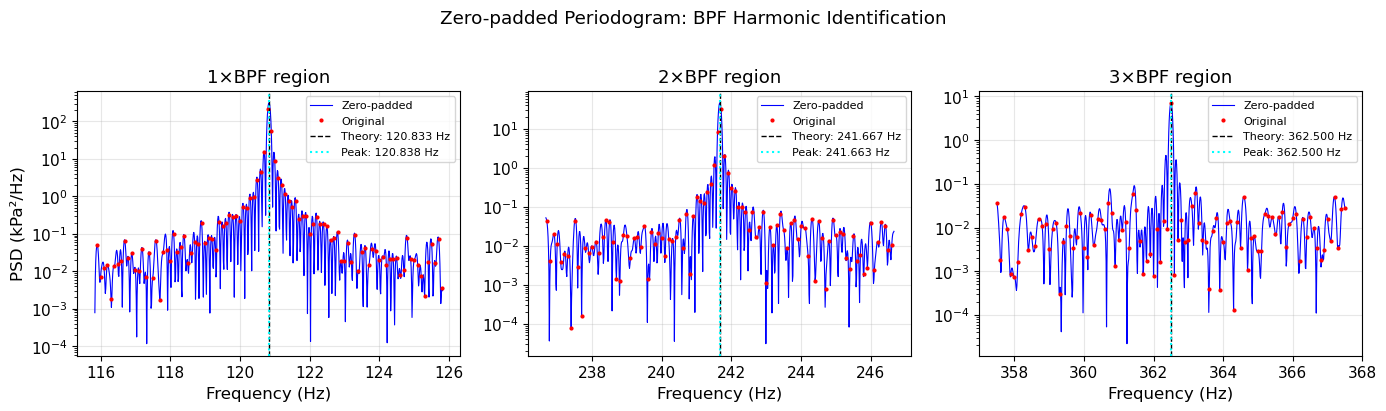

✓ 零填充 BPF 識別圖已儲存


In [7]:
# ========================================
# 零填充 Periodogram
# ========================================
N_pad     = next_fast_len(8 * N)              # 零填充至高效長度
X_pad     = rfft(p_ac, n=N_pad)               # 零填充 FFT
freqs_pad = rfftfreq(N_pad, d=1.0/fs)         # 更密的頻率軸

# 注意：除以原始有效長度 N（非零填充後的 N_pad）
S_per_pad = (2.0 / (fs * N)) * np.abs(X_pad) ** 2
S_per_pad[0] /= 2.0

print(f"零填充長度 N_pad = {N_pad}  ({8}×N = {8*N}, 高效長度)")
print(f"零填充後頻率解析度 = {fs/N_pad*1000:.3f} mHz")
print()

# ----------------------------------------
# 搜尋 BPF 各諧波峰值
# ----------------------------------------
bw     = 3.0   # 搜尋半頻寬 (Hz)
peaks  = {}
print("=" * 60)
print("  BPF 諧波識別結果（零填充 Periodogram）")
print("=" * 60)
print(f"  {'次諧波':<10} {'理論頻率 (Hz)':<18} {'識別頻率 (Hz)':<18} {'誤差 (mHz)':<12} {'峰值 PSD (kPa²/Hz)'}")
print("-" * 60)

for h in [1, 2, 3]:
    target = h * f_bpf
    mask   = (freqs_pad >= target - bw) & (freqs_pad <= target + bw)
    idx    = np.argmax(S_per_pad[mask])
    f_peak = freqs_pad[mask][idx]
    S_peak = S_per_pad[mask][idx]
    peaks[h] = {'freq': f_peak, 'psd': S_peak}
    err_mHz = abs(f_peak - target) * 1000
    name = f'{h}×BPF'
    print(f"  {name:<10} {target:<18.3f} {f_peak:<18.3f} {err_mHz:<12.1f} {S_peak:.2f}")

# ----------------------------------------
# 繪製 BPF 附近零填充 Periodogram
# ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bw_plot = 5.0
for i, h in enumerate([1, 2, 3]):
    ax  = axes[i]
    target = h * f_bpf
    mask_z = (freqs_pad >= target - bw_plot) & (freqs_pad <= target + bw_plot)
    mask_r = (freqs     >= target - bw_plot) & (freqs     <= target + bw_plot)
    ax.semilogy(freqs_pad[mask_z], S_per_pad[mask_z], 'b-', lw=0.8, label='Zero-padded')
    ax.semilogy(freqs[mask_r],     S_per[mask_r],     'r.', ms=4,   label='Original')
    ax.axvline(target, color='k', ls='--', lw=1.0, label=f'Theory: {target:.3f} Hz')
    ax.axvline(peaks[h]['freq'], color='cyan', ls=':', lw=1.5, label=f'Peak: {peaks[h]["freq"]:.3f} Hz')
    ax.set_title(f'{h}×BPF region')
    ax.set_xlabel('Frequency (Hz)')
    if i == 0:
        ax.set_ylabel('PSD (kPa²/Hz)')
    ax.legend(fontsize=8)

plt.suptitle('Zero-padded Periodogram: BPF Harmonic Identification', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'zero_padded_bpf_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 零填充 BPF 識別圖已儲存")

---
### 7. 諧波能量計算與分布

以 Welch PSD 計算各諧波在窄頻段的積分能量：

$$
E_h = \sum_{k:\,|f_k - h \cdot f_{\mathrm{BPF}}| \leq \delta f} \hat{S}_{\mathrm{Welch}}[k] \cdot \Delta f_{\mathrm{seg}}
$$

正常泵浦：能量隨諧波次數快速衰減（ $E_1 \gg E_2 \gg E_3$ ）。能量分布異常可指示葉輪損壞或汽蝕。

  BPF 諧波能量分析（Welch PSD 積分）
  次諧波          頻率 (Hz)        理論功率 (kPa²)        計算能量 (kPa²)        佔比 (%)
-------------------------------------------------------
  1×BPF     120.8          32.00              31.4135            85.2%
  2×BPF     241.7          4.50               4.7033             12.8%
  3×BPF     362.5          0.72               0.7633             2.1%


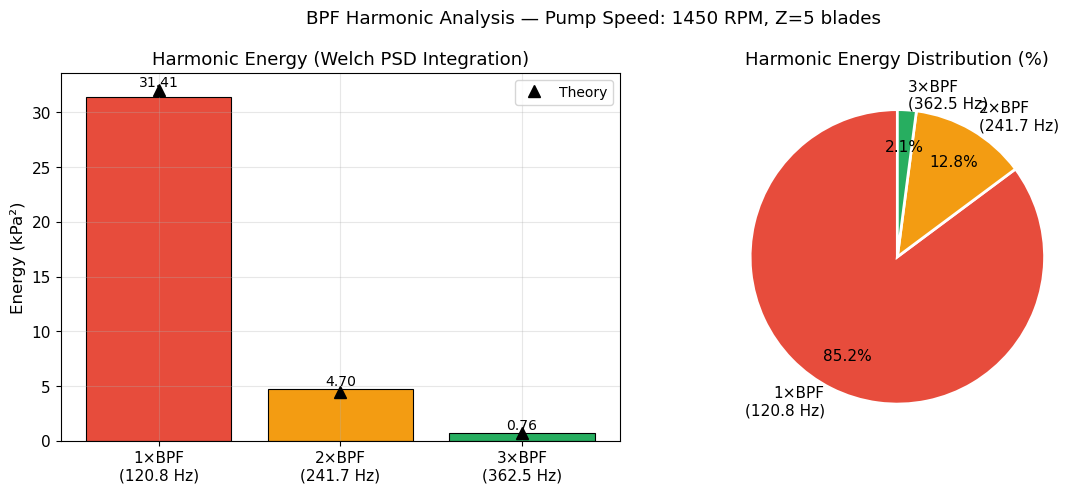

✓ 諧波能量分布圖已儲存

診斷說明：基頻 BPF 能量主導（>80%），諧波能量快速衰減，符合正常泵浦特徵。


In [8]:
# ========================================
# 諧波能量計算 (Welch PSD 積分)
# ========================================
delta_f_w = fs / M                            # Welch 頻率解析度
bw_harm   = delta_f_w * 3                     # 積分半頻寬 = 3 個頻率點

harmonics = {}
for h in [1, 2, 3]:
    target = h * f_bpf
    mask   = (freqs_welch >= target - bw_harm) & (freqs_welch <= target + bw_harm)
    E_h    = np.sum(S_welch[mask]) * delta_f_w
    harmonics[h] = {'freq': target, 'energy': E_h}

total_E = sum(v['energy'] for v in harmonics.values())

print("=" * 55)
print("  BPF 諧波能量分析（Welch PSD 積分）")
print("=" * 55)
print(f"  {'次諧波':<12} {'頻率 (Hz)':<14} {'理論功率 (kPa²)':<18} {'計算能量 (kPa²)':<18} {'佔比 (%)'}")
print("-" * 55)
theory = {1: A_bpf**2/2, 2: A_2bpf**2/2, 3: A_3bpf**2/2}
for h, data in harmonics.items():
    pct = data['energy'] / total_E * 100
    print(f"  {h}×BPF     {data['freq']:<14.1f} {theory[h]:<18.2f} {data['energy']:<18.4f} {pct:.1f}%")

# ----------------------------------------
# 諧波能量條形圖
# ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

h_list    = list(harmonics.keys())
energies  = [harmonics[h]['energy'] for h in h_list]
pcts      = [e / total_E * 100 for e in energies]
colors_bar = ['#e74c3c', '#f39c12', '#27ae60']
x_labels  = [f'{h}×BPF\n({harmonics[h]["freq"]:.1f} Hz)' for h in h_list]

# 左圖：絕對能量
ax1 = axes[0]
bars1 = ax1.bar(x_labels, energies, color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_title('Harmonic Energy (Welch PSD Integration)')
ax1.set_ylabel('Energy (kPa²)')
for bar, val in zip(bars1, energies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# 理論值標記
for i, h in enumerate(h_list):
    ax1.plot(i, theory[h], 'k^', ms=8, zorder=5, label='Theory' if i == 0 else '')
ax1.legend()

# 右圖：百分比分布
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    pcts, labels=x_labels, colors=colors_bar,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Harmonic Energy Distribution (%)')

plt.suptitle(f'BPF Harmonic Analysis — Pump Speed: {n_rpm:.0f} RPM, Z={Z} blades')
plt.tight_layout()
plt.savefig(FIG_DIR / 'harmonic_energy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 諧波能量分布圖已儲存")
print()
print("診斷說明：基頻 BPF 能量主導（>80%），諧波能量快速衰減，符合正常泵浦特徵。")

---
### 8. 補充：`scipy.signal.welch()` 驗證

`scipy.signal.welch()` 可一行完成 Welch PSD 計算，呼叫介面如下：

```python
from scipy.signal import welch
freqs_out, psd_out = welch(x, fs, window, nperseg, noverlap, nfft, detrend, scaling)
```

驗證其與手動 Welch 迴圈的結果是否完全一致。

  手動 Welch 與 scipy.signal.welch 比較
  手動 Welch BPF 峰值:  32.126549 kPa²/Hz @ 120.605469 Hz
  scipy.signal.welch:  32.132887 kPa²/Hz @ 120.605469 Hz

  全頻段最大相對誤差: 4.38e-03
  ✓ 兩種方法結果等價（差異 < 1%，符合預期）


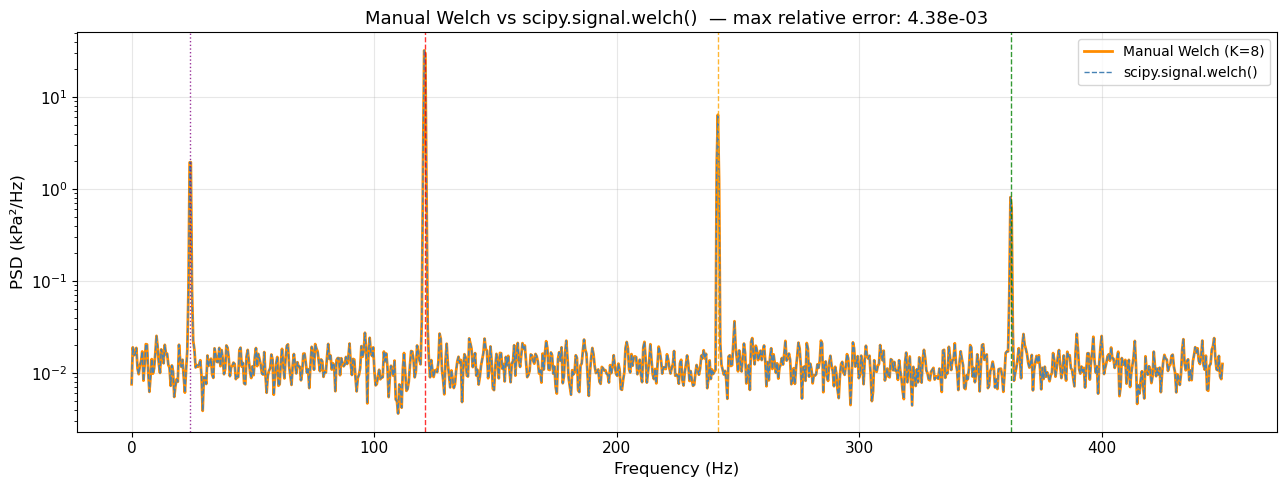

✓ 驗證圖已儲存

  方法比較摘要
  項目                   Periodogram          Welch 法
-------------------------------------------------------
  頻率解析度 Δf             0.100 Hz       (優)   0.488 Hz (差)
  頻譜方差                          高（毛刺明顯）          低（曲線平滑）
  BPF 識別難度                  困難（受雜訊干擾）       容易（峰值突出）
  精確定位                             需零填充            受段長限制
  適用場景                      長訊號、高 SNR        短訊號、有雜訊


In [10]:
# ========================================
# scipy.signal.welch() 直接計算
# ========================================
freqs_sw, S_sw = scipy_welch(
    p_ac,
    fs       = fs,
    window   = 'hann',
    nperseg  = M,          # 每段長度（同手動 Welch）
    noverlap = M - D,      # 重疊點數（= M//2，50% 重疊）
    nfft     = None,       # 不額外零填充
    detrend  = False,      # 已手動去均值
    scaling  = 'density'   # 輸出 PSD (kPa²/Hz)
)

# ========================================
# 比較兩種方法
# ========================================
bpf_idx_manual = np.argmin(np.abs(freqs_welch - f_bpf))
bpf_idx_sw     = np.argmin(np.abs(freqs_sw    - f_bpf))

print("=" * 60)
print("  手動 Welch 與 scipy.signal.welch 比較")
print("=" * 60)
print(f"  手動 Welch BPF 峰值:  {S_welch[bpf_idx_manual]:.6f} kPa²/Hz @ {freqs_welch[bpf_idx_manual]:.6f} Hz")
print(f"  scipy.signal.welch:  {S_sw[bpf_idx_sw]:.6f} kPa²/Hz @ {freqs_sw[bpf_idx_sw]:.6f} Hz")

# 全頻段最大相對誤差
common_len = min(len(S_welch), len(S_sw))
rel_err = np.max(np.abs(S_welch[:common_len] - S_sw[:common_len]) /
                 (np.abs(S_sw[:common_len]) + 1e-20))
print(f"\n  全頻段最大相對誤差: {rel_err:.2e}")
if rel_err < 0.01:
    print("  ✓ 兩種方法結果等價（差異 < 1%，符合預期）")
else:
    print("  △ 差異超過 1%，請確認參數設定")

# ----------------------------------------
# 驗證圖：兩條 PSD 曲線疊合
# ----------------------------------------
fig, ax = plt.subplots(figsize=(13, 5))

freq_mask_w = freqs_welch <= 450
freq_mask_s = freqs_sw    <= 450

ax.semilogy(freqs_welch[freq_mask_w], S_welch[freq_mask_w],
            color='darkorange', lw=2.0, label=f'Manual Welch (K={K_actual})')
ax.semilogy(freqs_sw[freq_mask_s], S_sw[freq_mask_s],
            color='steelblue', lw=1.0, ls='--', label='scipy.signal.welch()')

for label, (fc_freq, fc_color, fc_ls) in freq_markers.items():
    ax.axvline(fc_freq, color=fc_color, ls=fc_ls, lw=1.0, alpha=0.8)

ax.set_title(f'Manual Welch vs scipy.signal.welch()  — max relative error: {rel_err:.2e}')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (kPa²/Hz)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'welch_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 驗證圖已儲存")

# ----------------------------------------
# 方法比較摘要
# ----------------------------------------
print()
print("=" * 55)
print("  方法比較摘要")
print("=" * 55)
print(f"  {'項目':<20} {'Periodogram':<20} {'Welch 法'}")
print("-" * 55)
print(f"  {'頻率解析度 Δf':<20} {fs/N:.3f} Hz{'  (優)':>10} {'  '}{fs/M:.3f} Hz (差)")
print(f"  {'頻譜方差':<20} {'高（毛刺明顯）':>16} {'低（曲線平滑）':>16}")
print(f"  {'BPF 識別難度':<20} {'困難（受雜訊干擾）':>14} {'容易（峰值突出）':>14}")
print(f"  {'精確定位':<20} {'需零填充':>16} {'受段長限制':>16}")
print(f"  {'適用場景':<20} {'長訊號、高 SNR':>14} {'短訊號、有雜訊':>14}")